# Notebook: Fine-tune COCO→Cityscapes (EoMT) – Colab-ready

Este cuaderno guía: 1) smoke-test del checkpoint COCO, 2) evaluación baseline en Cityscapes (mIoU), 3) fine-tuning (head-only / gradual unfreeze) y 4) opción LoRA.

## 1) Setup: repo, dependencias y GPU (ejecutar en Colab)

In [1]:
%cd /content
# Clona el repo si estás en un entorno nuevo (Colab)
!git clone https://github.com/Escortiz/ML_RL.git || true
%cd /content/ML_RL/eomt
# Instala dependencias principales (usa el requirements del repo)
!pip install -r requirements.txt
# A veces conviene reinstalar PyTorch para la GPU de Colab (elige la URL correcta para tu runtime)
!pip install --upgrade pip
!pip uninstall -y torch torchvision torchaudio || true
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124 || true
# Comprueba GPU
!python -c "import torch; print('cuda:', torch.cuda.is_available(), 'device_count:', torch.cuda.device_count())"

/content
fatal: destination path 'ML_RL' already exists and is not an empty directory.
/content/ML_RL/eomt
  Using cached pip-26.1.2-py3-none-any.whl.metadata (4.6 kB)
Using cached pip-26.1.2-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Found existing installation: torch 2.7.0
Uninstalling torch-2.7.0:
  Successfully uninstalled torch-2.7.0
Found existing installation: torchvision 0.22.0
Uninstalling torchvision-0.22.0:
  Successfully uninstalled torchvision-0.22.0
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 124.4 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.9 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
else:
    print("--- INTENTANDO REINSTALACIÓN FORZADA PARA COLAB ---")
    # Esta línea suele solucionar el desajuste de drivers en los runtimes de Colab
    !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

PyTorch version: 2.6.0+cu124
CUDA available: False
--- INTENTANDO REINSTALACIÓN FORZADA PARA COLAB ---
Looking in indexes: https://download.pytorch.org/whl/cu124


In [6]:
# Actualizar wandb y lightning a las versiones más recientes
!pip install -U wandb lightning

import wandb
import torch
print(f"WandB version: {wandb.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.3/27.3 MB 112.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 47.4 MB/s  0:00:00
  Attempting uninstall: wandb
    Found existing installation: wandb 0.19.10
    Uninstalling wandb-0.19.10:
      Successfully uninstalled wandb-0.19.10
  Attempting uninstall: lightning
    Found existing installation: lightning 2.5.1.post0
    Uninstalling lightning-2.5.1.post0:
      Successfully uninstalled lightning-2.5.1.post0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [lightning]
WandB version: 0.19.10
PyTorch version: 2.6.0+cu124
CUDA available: True


In [9]:
# Solucionar conflicto de versiones entre Lightning y jsonargparse
!pip install -U "jsonargparse[signatures]>=4.27.7"

  Attempting uninstall: jsonargparse
    Found existing installation: jsonargparse 4.38.0
    Uninstalling jsonargparse-4.38.0:
      Successfully uninstalled jsonargparse-4.38.0


### Nota sobre el Runtime
Si después de ejecutar la celda anterior y **Reiniciar el entorno de ejecución** (Runtime -> Restart session) sigue saliendo `False`, asegúrate de que en `Entorno de ejecución -> Cambiar tipo de entorno de ejecución` esté seleccionada una GPU (T4, L4 o A100).

## 2) Datos: instrucciones rápidas para Cityscapes
- Cityscapes requiere cuenta y descarga manual; sube los zips `leftImg8bit_trainvaltest.zip` y `gtFine_trainvaltest.zip` a `/content/ML_RL/cityscapes_dataset` en Colab (o monta Drive).
- Asegúrate de que la estructura sea la esperada por `eomt/datasets/cityscapes_semantic.py`.

In [5]:
!rm -rf /content/ML_RL/cityscapes_dataset/gtFine

In [2]:
from google.colab import drive
import os

# 1. Montar Google Drive
drive.mount('/content/drive', force_remount=True)

# Rutas de Drive
drive_base = '/content/drive/MyDrive/ML_RL'
drive_anomaly_src = os.path.join(drive_base, 'anomaly_validation_datasets')
drive_cityscapes_src = os.path.join(drive_base, 'cityscapes_dataset')

# Rutas Locales
anomaly_local = '/content/ML_RL/anomaly_validation_datasets'
model_local = '/content/ML_RL/eomt/dataset_trained'
cityscapes_local = '/content/ML_RL/cityscapes_dataset'

# Crear directorios locales
for d in [anomaly_local, model_local, cityscapes_local]:
    os.makedirs(d, exist_ok=True)

print("--- 1. Copiando Modelos (.bin) ---")
models = ['eomt_cityscapes.bin', 'eomt_coco.bin']
for m in models:
    src = os.path.join(drive_base, m)
    if os.path.exists(src):
        !cp "{src}" "{model_local}/"
        print(f"Copiado: {m}")

print("\n--- 2. Copiando Anomaly Dataset ---")
if os.path.exists(drive_anomaly_src):
    !cp -r {drive_anomaly_src}/* {anomaly_local}/
    print("Dataset de anomalías copiado.")

print("\n--- 3. Copiando Cityscapes (solo ZIPs) ---")
if os.path.exists(drive_cityscapes_src):
    zips = [f for f in os.listdir(drive_cityscapes_src) if f.endswith('.zip')]
    for z in zips:
        src_zip = os.path.join(drive_cityscapes_src, z)
        !cp "{src_zip}" "{cityscapes_local}/"
        print(f"Copiado: {z}")
    print("Archivos ZIP de Cityscapes guardados en local.")
else:
    print(f"ERROR: No se encontró la carpeta {drive_cityscapes_src} en Drive.")

print("\nProceso finalizado.")

Mounted at /content/drive
--- 1. Copiando Modelos (.bin) ---
Copiado: eomt_cityscapes.bin
Copiado: eomt_coco.bin

--- 2. Copiando Anomaly Dataset ---

--- 3. Copiando Cityscapes (solo ZIPs) ---
Copiado: gtFine_trainvaltest.zip
Copiado: leftImg8bit_trainvaltest.zip
Archivos ZIP de Cityscapes guardados en local.

Proceso finalizado.


## 3) Smoke-test: cargar checkpoint COCO o Cityscapes y ejecutar una inferencia rápida
Este bloque adapta el código de `inference.ipynb` para cargar el config y el checkpoint y visualizar una muestra.

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Omitiendo network.encoder.backbone.pos_embed por desajuste de tamaño: Checkpoint torch.Size([1, 1600, 768]) vs Modelo torch.Size([1, 4096, 768])
Omitiendo network.q.weight por desajuste de tamaño: Checkpoint torch.Size([200, 768]) vs Modelo torch.Size([100, 768])
Omitiendo network.class_head.weight por desajuste de tamaño: Checkpoint torch.Size([134, 768]) vs Modelo torch.Size([20, 768])
Omitiendo network.class_head.bias por desajuste de tamaño: Checkpoint torch.Size([134]) vs Modelo torch.Size([20])
Omitiendo criterion.empty_weight por desajuste de tamaño: Checkpoint torch.Size([134]) vs Modelo torch.Size([20])

Checkpoint cargado parcialmente (pesos del backbone listos para fine-tuning).


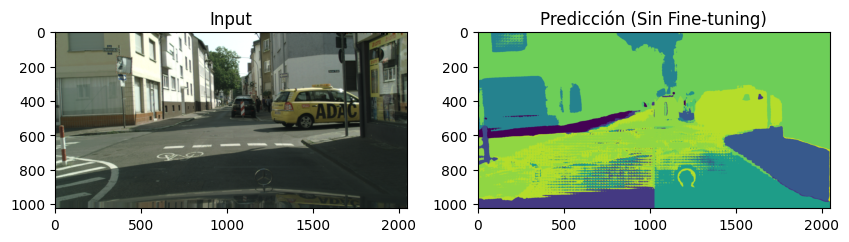

In [3]:
import yaml, importlib, warnings
import torch
from torch.nn import functional as F
from torch.amp.autocast_mode import autocast
import matplotlib.pyplot as plt
import numpy as np
from lightning import seed_everything
seed_everything(0, verbose=False)
device = 0 if torch.cuda.is_available() else 'cpu'

# Ajusta estas rutas según lo tengas en Colab
ACTIVE_YAML = '/content/ML_RL/eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml'
ACTIVE_WEIGHTS = '/content/ML_RL/eomt/dataset_trained/eomt_coco.bin'
DATA_PATH = '/content/ML_RL/cityscapes_dataset'

# Cargar config de modelo
with open(ACTIVE_YAML, 'r') as f:
    cfg = yaml.safe_load(f)

# Cargar DataModule
dm_module_name, dm_class = cfg['data']['class_path'].rsplit('.', 1)
dm_cls = getattr(importlib.import_module(dm_module_name), dm_class)

# Limpiar dm_kwargs para evitar duplicados
dm_kwargs = cfg['data'].get('init_args', {}).copy()
dm_kwargs.pop('num_workers', None)
dm_kwargs.pop('path', None)

# Nota: Si el dataset no está descomprimido, esto podría fallar al intentar leer imágenes.
dm = dm_cls(path=DATA_PATH, batch_size=1, num_workers=0, check_empty_targets=False, **dm_kwargs).setup()

# Build encoder + network + lit module
warnings.filterwarnings('ignore')

enc_cfg = cfg['model']['init_args']['network']['init_args']['encoder']
enc_mod, enc_cls = enc_cfg['class_path'].rsplit('.', 1)
Enc = getattr(importlib.import_module(enc_mod), enc_cls)
encoder = Enc(img_size=dm.img_size, **enc_cfg.get('init_args', {}))

net_cfg = cfg['model']['init_args']['network']
net_mod, net_cls = net_cfg['class_path'].rsplit('.', 1)
Net = getattr(importlib.import_module(net_mod), net_cls)
net_kwargs = {k: v for k, v in net_cfg.get('init_args', {}).items() if k != 'encoder'}
network = Net(masked_attn_enabled=False, num_classes=dm.num_classes, encoder=encoder, **net_kwargs)

lit_mod, lit_cls = cfg['model']['class_path'].rsplit('.', 1)
Lit = getattr(importlib.import_module(lit_mod), lit_cls)
model = Lit(img_size=dm.img_size, num_classes=dm.num_classes, network=network, **{k:v for k,v in cfg['model'].get('init_args', {}).items() if k!='network'}).eval().to(device)

# --- CARGA SEGURA DE CHECKPOINT (SOLUCIÓN AL ERROR) ---
state = torch.load(ACTIVE_WEIGHTS, map_location=f'cuda:{device}' if device!='cpu' else 'cpu', weights_only=False)
if 'state_dict' in state: state = state['state_dict']

# Filtramos las llaves que causan error de tamaño (cabeza y queries)
model_dict = model.state_dict()
filtered_state = {}
for k, v in state.items():
    if k in model_dict and v.shape == model_dict[k].shape:
        filtered_state[k] = v
    else:
        print(f"Omitiendo {k} por desajuste de tamaño: Checkpoint {v.shape} vs Modelo {model_dict[k].shape if k in model_dict else 'N/A'}")

model.load_state_dict(filtered_state, strict=False)
print('\nCheckpoint cargado parcialmente (pesos del backbone listos para fine-tuning).')

# Intentar inferencia si el dataset está disponible
try:
    img_idx = 0
    img, target = dm.val_dataloader().dataset[img_idx]
    with torch.no_grad(), autocast(dtype=torch.float16, device_type='cuda' if torch.cuda.is_available() else 'cpu'):
        imgs = [img.to(device)]
        crops, origins = model.window_imgs_semantic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model(crops)
        mask_logits = F.interpolate(mask_logits_per_layer[-1], dm.img_size, mode='bilinear')
        crop_logits = model.to_per_pixel_logits_semantic(mask_logits, class_logits_per_layer[-1])
        logits = model.revert_window_logits_semantic(crop_logits, origins, [img.shape[-2:]])
        preds = logits[0].argmax(0).cpu().numpy()

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(img.permute(1,2,0).cpu().numpy()); plt.title('Input')
    plt.subplot(1,2,2); plt.imshow(preds); plt.title('Predicción (Sin Fine-tuning)')
    plt.show()
except Exception as e:
    print(f"\nNo se pudo visualizar la imagen: {e}. \n(Asegúrate de descomprimir los ZIPs de Cityscapes si quieres ver resultados).")

## 4) Evaluación baseline (mIoU) en Cityscapes
Usa el `validate` del CLI o el script `eval_iou.py` incluido. Ejecuta en la carpeta `eomt` del repo.

In [10]:
# Ejemplo: ejecutar validación via CLI (ajusta rutas y dispositivos)
%cd /content/ML_RL/eomt
!python main.py validate \
  -c /content/ML_RL/eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml \
  --trainer.devices 1 \
  --data.batch_size 2 \
  --data.path /content/ML_RL/cityscapes_dataset \
  --model.ckpt_path /content/ML_RL/eomt/dataset_trained/eomt_cityscapes.bin

/content/ML_RL/eomt
Seed set to 0
INFO:root:Loaded 197 keys
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: 2
wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wan

In [22]:
%cd /content/ML_RL/eomt
!python main.py validate \
  -c /content/ML_RL/eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml \
  --trainer.devices 1 \
  --data.batch_size 2 \
  --data.path /content/ML_RL/cityscapes_dataset \
  --data.init_args.img_size "[640, 640]" \
  --model.ckpt_path /content/ML_RL/eomt/dataset_trained/eomt_coco.bin \
  --model.load_ckpt_class_head False \
  --model.network.init_args.num_q 200 \
  --model.network.init_args.encoder.init_args.img_size "[640, 640]"

/content/ML_RL/eomt
Seed set to 0
INFO:root:Loaded 195 keys
Traceback (most recent call last):
  File "/content/ML_RL/eomt/main.py", line 184, in <module>
    cli_main()
  File "/content/ML_RL/eomt/main.py", line 161, in cli_main
    LightningCLI(
  File "/content/ML_RL/eomt/main.py", line 111, in __init__
    super().__init__(*args, **kwargs)
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/cli.py", line 417, in __init__
    self.instantiate_classes()
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/cli.py", line 612, in instantiate_classes
    self.config_init = self.parser.instantiate_classes(self.config)
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/jsonargparse/_deprecated.py", line 103, in decorated
    return component(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/jsonargparse/_deprecated.py", line 703, in instantiate_cl

## 5) Fine-tuning: comandos recomendados
- Fine-tune completo (start from COCO checkpoint): pasar `--model.ckpt_path` y opcionalmente `--model.load_ckpt_class_head False` si las clases difieren.
- Para ahorrar memoria: usar `--trainer.accumulate_grad_batches`, `--data.batch_size` pequeño y `--compile_disabled` si `torch.compile` da problemas.

In [ ]:
# Ejemplo: fine-tune desde checkpoint COCO (ajusta batch y devices para Colab)
%cd /content/ML_RL/eomt
!python main.py fit \
  -c configs/dinov2/cityscapes/semantic/eomt_base_640.yaml \
  --trainer.devices 1 \
  --data.batch_size 2 \
  --trainer.accumulate_grad_batches 8 \
  --data.path /content/ML_RL/cityscapes_dataset \
  --model.ckpt_path /content/ML_RL/eomt/dataset_trained/eomt_coco.bin \
  --model.load_ckpt_class_head False \
  --compile_disabled

### 5.a Head-only / freeze encoder (opción)
Si quieres entrenar solo la cabeza, hay dos caminos: 1) modificar el código para congelar `network.encoder` en el LightningModule, o 2) usar un pequeño wrapper que instancie el modelo, congele parámetros y lance un `Trainer` de Lightning.

In [ ]:
# Ejemplo ilustrativo: freeze encoder y ejecutar unas pocas épocas con Trainer (no usa la CLI).
# Puede requerir ajustes según la implementación interna del LightningModule.
from lightning.pytorch import Trainer
import yaml, importlib, torch
with open('/content/ML_RL/eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml','r') as f: cfg=yaml.safe_load(f)
# Instancia modelos igual que en la celda de inferencia (omito detalles por brevedad)
# SUPONiendo que `lit_module` es la instancia del LightningModule:
# for p in lit_module.network.encoder.parameters():
#     p.requires_grad = False
# trainer = Trainer(devices=1, accelerator='gpu', max_epochs=3, precision='16-mixed')
# trainer.fit(lit_module, datamodule=dm)
print('Ejemplo de congelado: insértalo en tu flujo o pide ayuda para implementarlo en el repo si quieres que lo automatice.')

## 6) Gradual unfreeze (estrategia)
- Entrena la cabeza 3-5 épocas. Luego descongela las últimas N capas del encoder y continúa. Repite hasta descongelar todo.
- Registra mIoU tras cada etapa y compara con baseline.
- Usa learning rate menor para las capas descongeladas (por ejemplo, 0.1× la lr principal).

## 7) Opcional: LoRA (baja memoria) — guía rápida
- LoRA no está implementado nativamente en este repo. Para integrarlo, considera usar `loralib` o `peft` y adaptar las llamadas al `encoder` (aplicar adaptadores a los bloques de atención).
- Alternativa práctica: head-only → gradual unfreeze; implementar LoRA solo si necesitas mejor eficiencia y estás cómodo editando `models/eomt.py` para inyectar adapters.

## 8) Guardar resultados y comparar mIoU
- Tras cada experimento, ejecuta `!python eval_iou.py --datadir /content/ML_RL/cityscapes_dataset --subset val` para obtener mIoU.
- Guarda las métricas en un CSV (wandb o local) y compara la línea base (checkpoint proporcionado) frente a tu modelo fine-tuned.

In [12]:
# Configurar identidad de Git
!git config --global user.email "escortiz@example.com"
!git config --global user.name "Escortiz"

%cd /content/ML_RL


# Crear o cambiar a la rama COCO-fine-tunning
!git checkout COCO-fine-tunning

# Añadir cambios
!git add .


# Hacer commit de los cambios
!git commit -m "Update notebook and configs for COCO fine-tuning on Cityscapes"

# Realizar el push
# Nota: Si falla, puede que necesites un token de acceso personal (PAT) configurado en el remote
print("Intentando realizar el push a la rama COCO-fine-tunning...")
!git push origin COCO-fine-tunning

/content/ML_RL
Already on 'COCO-fine-tunning'
Your branch is up to date with 'origin/COCO-fine-tunning'.
On branch COCO-fine-tunning
Your branch is up to date with 'origin/COCO-fine-tunning'.

nothing to commit, working tree clean
Intentando realizar el push a la rama COCO-fine-tunning...
fatal: could not read Username for 'https://github.com': No such device or address
